# ATML PA1 · Task 4D — PROSER

This notebook implements the required **PROSER classifier + data placeholders** experiment for Task 4.

Protocol:
- initialize from the **selected Vanilla checkpoint**;
- append **5 randomly initialized dummy classifiers**;
- fine-tune the complete CIFAR ResNet-18 for **50 epochs**;
- SGD, learning rate `1e-3`, momentum `0.9`, weight decay `5e-4`, cosine decay;
- batch size `128`, seed `6304`;
- classifier-placeholder coefficient **β = 1**;
- data-placeholder coefficient **γ = 0.1**;
- split each mini-batch into equal halves;
- classifier placeholders on the first half;
- manifold-mixup data placeholders on the second half;
- mix **after layer2 and before layer3** with λ ~ Beta(2,2);
- select the checkpoint using **CIFAR-10 validation accuracy only**;
- calibrate the placeholder detector using **CIFAR-10 validation only**;
- **never load CIFAR-100 or CIFAR-10 test data in this notebook**.

For multiple dummy classifiers, PROSER uses the **strongest dummy logit** as the aggregate placeholder response. The notebook keeps all five dummy weights trainable, while the max operation routes each example's placeholder gradient through its strongest dummy.


## Cell 1 — Mount Drive and imports

This cell prepares the runtime. Use a **T4 GPU**.


In [1]:
#! Import dependencies and mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import hashlib
import json
import math
import os
import random
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type != 'cuda':
    raise RuntimeError('Select Runtime > Change runtime type > T4 GPU before training Task 4D.')

print('PyTorch:', torch.__version__, '| device:', torch.cuda.get_device_name(0))


Mounted at /content/drive
PyTorch: 2.11.0+cu128 | device: Tesla T4


## Cell 2 — Paths, prerequisites, and immutable PROSER configuration

Task 4A must already be complete. This notebook only reads the shared Task 4 model utilities, the exact CIFAR-10 split, and the selected Vanilla checkpoint. It writes only inside PROSER-specific folders.


In [2]:
#! Fix the assignment protocol and isolate every PROSER artifact
ROOT = Path('/content/drive/MyDrive/pa1-beyond-iid')
TASK = ROOT / 'task4'
CODE_DIR = TASK / 'code'
DATA_DIR = TASK / 'data' / 'cifar10'
SPLIT_FILE = TASK / 'splits' / 'cifar10_stratified_90_10_seed6304.npz'

VANILLA_BEST = TASK / 'checkpoints' / 'vanilla' / 'best.pt'
VANILLA_LAST = TASK / 'checkpoints' / 'vanilla' / 'last.pt'
CORE_FILE = CODE_DIR / 'cifar_osr_core_v1.py'

CONFIG_DIR = TASK / 'configs'
CKPT_DIR = TASK / 'checkpoints' / 'proser'
RESULT_DIR = TASK / 'results' / 'proser'
CACHE_DIR = TASK / 'cache' / 'proser'
for directory in [CONFIG_DIR, CKPT_DIR, RESULT_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SEED = 6304
EPOCHS = 50
BATCH_SIZE = 128
NUM_WORKERS = 2
LR = 1e-3
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
NUM_KNOWN = 10
NUM_DUMMY = 5
BETA = 1.0
GAMMA = 0.1
MIX_ALPHA = 2.0
PLACEHOLDER_TEMPERATURE = 1024.0

CONFIG_FILE = CONFIG_DIR / 'proser.json'
BEST_PATH = CKPT_DIR / 'best.pt'
LAST_PATH = CKPT_DIR / 'last.pt'
HISTORY_FILE = RESULT_DIR / 'history.csv'
CALIBRATION_FILE = RESULT_DIR / 'calibration.json'
VAL_CACHE = CACHE_DIR / 'known_val_logits.npz'

required = [SPLIT_FILE, VANILLA_BEST, VANILLA_LAST, CORE_FILE]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('Finish Task 4A first. Missing:\n' + '\n'.join(missing))

vanilla_last = torch.load(VANILLA_LAST, map_location='cpu', weights_only=False)
if vanilla_last.get('epoch') != 100 or not vanilla_last.get('finished', False):
    raise RuntimeError('Task 4A Vanilla training must finish all 100 epochs before PROSER.')

SPLIT_SHA = hashlib.sha256(SPLIT_FILE.read_bytes()).hexdigest()
VANILLA_SHA = hashlib.sha256(VANILLA_BEST.read_bytes()).hexdigest()
vanilla_best = torch.load(VANILLA_BEST, map_location='cpu', weights_only=False)
if vanilla_best.get('split_sha256') != SPLIT_SHA:
    raise RuntimeError('Vanilla checkpoint and Task 4 split do not match.')

CONFIG = {
    'experiment': 'task4_proser',
    'seed': SEED,
    'initialization': 'selected Task 4A Vanilla checkpoint',
    'vanilla_best_sha256': VANILLA_SHA,
    'architecture': 'CIFAR ResNet-18, 10 known classifiers + 5 dummy classifiers',
    'dummy_aggregation': 'maximum dummy logit',
    'optimizer': 'SGD',
    'learning_rate': LR,
    'momentum': MOMENTUM,
    'weight_decay': WEIGHT_DECAY,
    'scheduler': 'CosineAnnealingLR T_max=50 eta_min=0',
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'beta_classifier_placeholder': BETA,
    'gamma_data_placeholder': GAMMA,
    'batch_split': 'first half classifier placeholders; second half manifold mixup',
    'mix_layer': 'after layer2 before layer3',
    'mix_lambda': 'Beta(2,2)',
    'selection': 'highest CIFAR-10 validation accuracy using ten known logits only',
    'placeholder_temperature': PLACEHOLDER_TEMPERATURE,
    'calibration': 'CIFAR-10 validation only; target 95% known acceptance',
    'precision': 'float32',
}
CONFIG_SHA = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()

if CONFIG_FILE.exists():
    if json.loads(CONFIG_FILE.read_text()) != CONFIG:
        raise RuntimeError('Existing PROSER configuration differs. Inspect before resuming.')
else:
    CONFIG_FILE.write_text(json.dumps(CONFIG, indent=2) + '\n')

print('Split SHA256:', SPLIT_SHA)
print('Vanilla best SHA256:', VANILLA_SHA)
print('PROSER configuration SHA256:', CONFIG_SHA)


Split SHA256: 58e3e0a58ca34ebab457ec178874817e597302512f91228ec13a69420b6164d8
Vanilla best SHA256: da0fd3c0459e44ce78e171eddca199ec0161ffdb203fdabad1fbb7a28a91f704
PROSER configuration SHA256: 2237be0e6618b40c08d22f1b3d05cd76888cf6a8eba4e6230c9e115ed772af87


## Cell 3 — Reuse the exact Task 4 model and exact CIFAR-10 split

No shared Python file is created or overwritten here. PROSER imports the stable Task 4A module exactly as it already exists.


In [3]:
#! Import the existing Task 4 core and audit the immutable 45k/5k split
sys.path.insert(0, str(CODE_DIR)) if str(CODE_DIR) not in sys.path else None
from cifar_osr_core_v1 import (
    seed_all, make_resnet18, training_transform, evaluation_transform,
    atomic_torch_save,
)

with np.load(SPLIT_FILE) as split:
    train_idx = split['train_idx'].astype(np.int64)
    val_idx = split['val_idx'].astype(np.int64)

raw_train = datasets.CIFAR10(root=str(DATA_DIR), train=True, download=True)
targets = np.asarray(raw_train.targets, dtype=np.int64)

if (len(train_idx) != 45000 or len(val_idx) != 5000
        or len(np.unique(np.concatenate((train_idx, val_idx)))) != 50000
        or np.any(np.bincount(targets[train_idx], minlength=10) != 4500)
        or np.any(np.bincount(targets[val_idx], minlength=10) != 500)):
    raise RuntimeError('Task 4 CIFAR-10 split audit failed.')

train_dataset = Subset(
    datasets.CIFAR10(root=str(DATA_DIR), train=True, download=False,
                     transform=training_transform(False)),
    train_idx.tolist()
)
val_dataset = Subset(
    datasets.CIFAR10(root=str(DATA_DIR), train=True, download=False,
                     transform=evaluation_transform()),
    val_idx.tolist()
)

train_generator = torch.Generator()
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False,
    num_workers=NUM_WORKERS, pin_memory=True, generator=train_generator
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

if len(train_dataset) != 45000 or len(val_dataset) != 5000:
    raise RuntimeError('PROSER must reuse the exact Task 4 45k/5k split.')

print('Training:', len(train_dataset), '| validation:', len(val_dataset))
print('CIFAR-100 and CIFAR-10 test partitions have not been loaded.')


Training: 45000 | validation: 5000
CIFAR-100 and CIFAR-10 test partitions have not been loaded.


## Cell 4 — PROSER model paths and losses

The ten known classifiers come from the selected Vanilla model. Five new dummy classifiers share the same 512-D representation.

For ordinary known examples:
1. cross-entropy keeps the correct known class largest;
2. after masking the correct known logit, a second cross-entropy pushes the strongest dummy response above all remaining known classes.

For data placeholders, the second half of a mini-batch is mixed at the layer2 representation using pairs from different classes and λ ~ Beta(2,2). The mixed representation is trained toward the aggregate dummy class.


In [4]:
#! Define PROSER without modifying the shared ResNet implementation
def forward_to_layer2(model, images):
    x = model.conv1(images)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)
    x = model.layer1(x)
    x = model.layer2(x)
    return x

def forward_from_layer2(model, hidden):
    x = model.layer3(hidden)
    x = model.layer4(x)
    features = torch.flatten(model.avgpool(x), 1)
    known_logits = model.fc(features)
    return features, known_logits

def forward_proser(model, dummy_head, images):
    hidden = forward_to_layer2(model, images)
    features, known_logits = forward_from_layer2(model, hidden)
    dummy_logits = dummy_head(features)
    return features, known_logits, dummy_logits

def strongest_dummy(dummy_logits):
    return dummy_logits.max(dim=1, keepdim=True).values

def augmented_logits(known_logits, dummy_logits):
    #! Multiple PROSER placeholders are represented by the strongest dummy response.
    return torch.cat((known_logits, strongest_dummy(dummy_logits)), dim=1)

def classifier_placeholder_losses(known_logits, dummy_logits, labels):
    #! Eq. 5 structure: preserve the known target and make dummy second strongest.
    full = augmented_logits(known_logits, dummy_logits)
    known_ce = F.cross_entropy(full, labels)

    masked_known = known_logits.clone()
    masked_known.scatter_(1, labels.view(-1, 1), -1e9)
    masked = torch.cat((masked_known, strongest_dummy(dummy_logits)), dim=1)
    dummy_targets = torch.full_like(labels, NUM_KNOWN)
    second_place_ce = F.cross_entropy(masked, dummy_targets)

    return known_ce + BETA * second_place_ce, known_ce, second_place_ce

def different_class_permutation(labels, max_attempts=256):
    #! Every manifold-mixup pair must come from two different CIFAR-10 classes.
    n = labels.numel()
    if n < 2 or torch.unique(labels).numel() < 2:
        raise RuntimeError('Cannot construct different-class PROSER pairs from this half-batch.')
    for _ in range(max_attempts):
        perm = torch.randperm(n, device=labels.device)
        if bool(torch.all(labels != labels[perm])):
            return perm
    raise RuntimeError(
        'Could not construct an all-different-class permutation. '
        'Inspect this unusually imbalanced half-batch.'
    )

def data_placeholder_loss(model, dummy_head, images, labels):
    hidden = forward_to_layer2(model, images)
    perm = different_class_permutation(labels)

    beta_dist = torch.distributions.Beta(
        torch.tensor(MIX_ALPHA, device=images.device),
        torch.tensor(MIX_ALPHA, device=images.device)
    )
    lam = beta_dist.sample()
    mixed_hidden = lam * hidden + (1.0 - lam) * hidden[perm]

    features, known_logits = forward_from_layer2(model, mixed_hidden)
    dummy_logits = dummy_head(features)
    mixed_logits = augmented_logits(known_logits, dummy_logits)
    dummy_targets = torch.full(
        (mixed_logits.shape[0],), NUM_KNOWN,
        dtype=torch.long, device=mixed_logits.device
    )
    loss = F.cross_entropy(mixed_logits, dummy_targets)
    return loss, float(lam.detach().cpu())

def proser_batch_loss(model, dummy_head, images, labels):
    #! Assignment protocol: equal halves, classifier placeholders then data placeholders.
    if images.shape[0] % 2 != 0:
        raise RuntimeError('PROSER requires an even mini-batch size.')
    half = images.shape[0] // 2
    if half == 0:
        raise RuntimeError('PROSER mini-batch is too small.')

    cls_images, cls_labels = images[:half], labels[:half]
    mix_images, mix_labels = images[half:], labels[half:]

    _, known_logits, dummy_logits = forward_proser(model, dummy_head, cls_images)
    l_classifier, known_ce, second_ce = classifier_placeholder_losses(
        known_logits, dummy_logits, cls_labels
    )
    l_data, lam = data_placeholder_loss(model, dummy_head, mix_images, mix_labels)
    total = l_classifier + GAMMA * l_data

    return total, {
        'classifier_loss': l_classifier.detach(),
        'known_ce': known_ce.detach(),
        'second_place_ce': second_ce.detach(),
        'data_placeholder_loss': l_data.detach(),
        'mix_lambda': lam,
    }

print('PROSER model paths and losses: ready')


PROSER model paths and losses: ready


## Cell 5 — Initialize from Vanilla and run independent gradient tests

Only the five dummy classifiers are random. The entire Vanilla model is loaded from Task 4A's selected checkpoint and then fine-tuned jointly with the dummy head.


In [5]:
#! Load selected Vanilla weights and create five reproducible random dummy classifiers
seed_all(SEED)
model = make_resnet18(NUM_KNOWN)
model.load_state_dict(vanilla_best['model_state_dict'], strict=True)
model = model.to(DEVICE)

seed_all(SEED)
dummy_head = nn.Linear(model.fc.in_features, NUM_DUMMY).to(DEVICE)

optimizer = torch.optim.SGD(
    list(model.parameters()) + list(dummy_head.parameters()),
    lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=0.
)

#! Synthetic test: correct shapes, different-class mixup, finite loss, gradients everywhere
test_model = make_resnet18(NUM_KNOWN).to(DEVICE)
test_dummy = nn.Linear(test_model.fc.in_features, NUM_DUMMY).to(DEVICE)
test_images = torch.randn(8, 3, 32, 32, device=DEVICE)
test_labels = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7], device=DEVICE)

test_loss, test_parts = proser_batch_loss(
    test_model, test_dummy, test_images, test_labels
)
if not bool(torch.isfinite(test_loss)):
    raise RuntimeError('Synthetic PROSER loss is non-finite.')
test_loss.backward()
if (not any(p.grad is not None for p in test_model.parameters())
        or not all(p.grad is not None for p in test_dummy.parameters())):
    raise RuntimeError('PROSER synthetic backward did not reach model and dummy classifiers.')

with torch.no_grad():
    _, k, d = forward_proser(test_model, test_dummy, test_images)
if k.shape != (8, 10) or d.shape != (8, 5) or augmented_logits(k, d).shape != (8, 11):
    raise RuntimeError('PROSER output shapes are incorrect.')

del test_model, test_dummy, test_images, test_labels, test_loss, test_parts, k, d
torch.cuda.empty_cache()

print('Vanilla initialization loaded.')
print('Five dummy classifiers initialized.')
print('PROSER synthetic forward/backward test: PASS')


Vanilla initialization loaded.
Five dummy classifiers initialized.
PROSER synthetic forward/backward test: PASS


## Cell 6 — Validation and safe resumption

Checkpoint selection uses only **CIFAR-10 validation accuracy computed from the ten known logits**. Dummy responses do not decide which epoch is selected.


In [6]:
#! Validation uses ten known logits only; resume only complete committed epochs
@torch.inference_mode()
def validation_metrics(net, loader):
    net.eval()
    correct, count, loss_sum = 0, 0, 0.0
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        logits = net(images)
        loss = F.cross_entropy(logits, labels)
        if not bool(torch.isfinite(loss)):
            raise FloatingPointError('Non-finite PROSER validation loss.')
        count += labels.size(0)
        correct += int((logits.argmax(1) == labels).sum().item())
        loss_sum += float(loss) * labels.size(0)
    if count != 5000:
        raise RuntimeError('Validation must contain exactly 5,000 CIFAR-10 examples.')
    return {'accuracy': correct / count, 'loss': loss_sum / count}

history = []
best_acc, best_epoch, start_epoch = -1.0, 0, 1
best_model_state = None
best_dummy_state = None

if LAST_PATH.exists():
    state = torch.load(LAST_PATH, map_location='cpu', weights_only=False)
    for key, expected in [
        ('config_sha256', CONFIG_SHA),
        ('split_sha256', SPLIT_SHA),
        ('vanilla_checkpoint_sha256', VANILLA_SHA),
    ]:
        if state.get(key) != expected:
            raise RuntimeError('Refusing incompatible PROSER resume: ' + key)

    model.load_state_dict(state['model_state_dict'], strict=True)
    dummy_head.load_state_dict(state['dummy_state_dict'], strict=True)
    optimizer.load_state_dict(state['optimizer_state_dict'])
    scheduler.load_state_dict(state['scheduler_state_dict'])
    history = list(state['history'])
    best_acc = float(state['best_val_accuracy'])
    best_epoch = int(state['best_epoch'])
    best_model_state = state['best_model_state_dict']
    best_dummy_state = state['best_dummy_state_dict']
    start_epoch = int(state['epoch']) + 1

    if len(history) != start_epoch - 1 or best_epoch < 1:
        raise RuntimeError('PROSER last checkpoint and history disagree.')

    #! Repair a best-file write interrupted after the fully committed last checkpoint.
    repair_best = (not BEST_PATH.exists())
    if not repair_best:
        current_best = torch.load(BEST_PATH, map_location='cpu', weights_only=False)
        repair_best = (
            current_best.get('epoch') != best_epoch
            or float(current_best.get('best_val_accuracy', -1.0)) != best_acc
        )
    if repair_best:
        atomic_torch_save({
            'method': 'proser', 'epoch': best_epoch, 'seed': SEED,
            'best_val_accuracy': best_acc,
            'config_sha256': CONFIG_SHA, 'split_sha256': SPLIT_SHA,
            'vanilla_checkpoint_sha256': VANILLA_SHA,
            'model_state_dict': best_model_state,
            'dummy_state_dict': best_dummy_state,
        }, BEST_PATH)
        print('Repaired PROSER best checkpoint from committed last checkpoint.')

    print('Resuming at epoch:', start_epoch, '| best:', best_epoch, best_acc)

elif BEST_PATH.exists():
    raise RuntimeError('PROSER best checkpoint exists without last checkpoint; inspect before continuing.')
else:
    print('Starting PROSER fine-tuning from epoch 1.')

print('Checkpoint and validation helpers: ready')


Starting PROSER fine-tuning from epoch 1.
Checkpoint and validation helpers: ready


## Cell 7 — Fine-tune PROSER for 50 epochs

Training is deliberately float32. No CIFAR-100 image is loaded or used. Every completed epoch is checkpointed so a disconnected Colab session can resume safely.


In [8]:
def different_class_permutation(labels, max_attempts=None):
    """
    Return a permutation `perm` such that:

        labels[i] != labels[perm[i]]

    for every i.

    The mapping is a true permutation, so every sample is used
    exactly once.

    A valid permutation exists iff no class occupies more than
    half of the supplied labels.
    """
    if labels.ndim != 1:
        raise ValueError(
            f'labels must be 1-D, got shape {tuple(labels.shape)}.'
        )

    n = labels.numel()

    if n < 2:
        raise RuntimeError(
            'Need at least two samples to construct a '
            'different-class permutation.'
        )

    _, counts = torch.unique(labels, return_counts=True)

    max_count = int(counts.max().item())

    if 2 * max_count > n:
        raise RuntimeError(
            'Cannot construct an all-different-class permutation: '
            f'largest class contains {max_count}/{n} samples.'
        )
    order = torch.argsort(labels, stable=True)

    shifted = torch.roll(order, shifts=-max_count, dims=0)

    perm = torch.empty_like(order)
    perm[order] = shifted

    # Defensive verification.
    if not bool(torch.all(labels != labels[perm])):
        bad = int((labels == labels[perm]).sum().item())

        raise RuntimeError('Internal error while constructing different-class ' f'permutation: {bad} same-class pairs remain.')

    # Make sure every index occurs exactly once.
    if torch.unique(perm).numel() != n:
        raise RuntimeError('Internal error: generated mapping is not a true permutation.')
    return perm

if LAST_PATH.exists():

    rollback = torch.load(LAST_PATH, map_location='cpu', weights_only=False)

    # Verify that the checkpoint belongs to THIS exact experiment.
    if (
        rollback['config_sha256'] != CONFIG_SHA
        or rollback['split_sha256'] != SPLIT_SHA
        or rollback['vanilla_checkpoint_sha256'] != VANILLA_SHA
    ):
        raise RuntimeError('PROSER rollback checkpoint metadata mismatch.')

    # Restore model.
    model.load_state_dict(rollback['model_state_dict'], strict=True)

    # Restore dummy classifier.
    dummy_head.load_state_dict(rollback['dummy_state_dict'], strict=True)

    # Restore optimizer and scheduler.
    optimizer.load_state_dict(rollback['optimizer_state_dict'])
    scheduler.load_state_dict(rollback['scheduler_state_dict'])

    history = list(rollback['history'])

    best_acc = float(rollback['best_val_accuracy'])
    best_epoch = int(rollback['best_epoch'])
    best_model_state = rollback['best_model_state_dict']
    best_dummy_state = rollback['best_dummy_state_dict']

    start_epoch = int(rollback['epoch']) + 1


else:

    # Start from the selected best Vanilla classifier.
    model.load_state_dict(vanilla_best['model_state_dict'], strict=True)

    seed_all(SEED)

    dummy_head = nn.Linear(model.fc.in_features, NUM_DUMMY).to(DEVICE)

    # Fine-tune BOTH:
    #   1. Complete Vanilla model
    #   2. Dummy classifier head
    optimizer = torch.optim.SGD(list(model.parameters()) + list(dummy_head.parameters()), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

    # Cosine learning-rate decay over exactly EPOCHS epochs.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=0.0)

    history = []

    best_acc = -1.0
    best_epoch = 0

    start_epoch = 1

    best_model_state = None
    best_dummy_state = None


print('Verified complete-epoch starting point:', start_epoch)

if start_epoch > EPOCHS:

    print(f'All {EPOCHS} PROSER epochs already finished: ''reusing saved checkpoint.')

else:
    for epoch in range(start_epoch, EPOCHS + 1):
        start = time.perf_counter()
        seed_all(SEED + epoch)

        train_generator.manual_seed(SEED + 1009 * epoch)
-------
        model.train()
        dummy_head.train()

        epoch_lr = optimizer.param_groups[0]['lr']

        # Running averages.
        sums = {
            'total': 0.0,
            'classifier': 0.0,
            'known_ce': 0.0,
            'second_ce': 0.0,
            'data': 0.0,
            'lambda': 0.0
        }

        seen = 0
        steps = 0

        for step, (images, labels) in enumerate(train_loader):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            # PROSER construction requires equal halves.
            if images.shape[0] % 2 != 0:
                raise RuntimeError('Every PROSER batch must split into equal halves.')

            optimizer.zero_grad(set_to_none=True)
            loss, parts = proser_batch_loss(model, dummy_head, images, labels)

            if not bool(torch.isfinite(loss)):
                raise FloatingPointError(f'Non-finite PROSER loss at ' f'epoch {epoch}, batch {step}.')

            loss.backward()

            if step % 100 == 0:

                bad_model = any(p.grad is not None and not bool(torch.isfinite(p.grad).all())
                    for p in model.parameters())

                bad_dummy = any(p.grad is not None and not bool(torch.isfinite(p.grad).all())
                    for p in dummy_head.parameters())

                if bad_model or bad_dummy:
                    raise FloatingPointError(f'Non-finite PROSER gradient at ' f'epoch {epoch}, batch {step}.')

            optimizer.step()

            n = labels.size(0)

            seen += n
            steps += 1

            sums['total'] += float(loss.detach())
            sums['classifier'] += float(parts['classifier_loss'])
            sums['known_ce'] += float(parts['known_ce'])
            sums['second_ce'] += float(parts['second_place_ce'])
            sums['data'] += float(parts['data_placeholder_loss'])
            sums['lambda'] += float(parts['mix_lambda'])


        if seen != 45000:
            raise RuntimeError('Each PROSER epoch must process exactly ' f'45,000 training examples; got {seen}.')


        val = validation_metrics(model, val_loader)
        improved = (val['accuracy'] > best_acc + 1e-12)

        if improved:
            best_acc = float(val['accuracy'])
            best_epoch = epoch

            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

            best_dummy_state = {k: v.detach().cpu().clone() for k, v in dummy_head.state_dict().items()}


        history.append({
            'epoch':
                epoch,

            'learning_rate':
                epoch_lr,

            'train_total_loss':
                sums['total'] / steps,

            'train_classifier_loss':
                sums['classifier'] / steps,

            'train_known_ce':
                sums['known_ce'] / steps,

            'train_second_place_ce':
                sums['second_ce'] / steps,

            'train_data_placeholder_loss':
                sums['data'] / steps,

            'mean_mix_lambda':
                sums['lambda'] / steps,

            'val_loss':
                val['loss'],

            'val_accuracy':
                val['accuracy'],

            'best_val_accuracy':
                best_acc,

            'best_epoch':
                best_epoch,

            'elapsed_seconds':
                time.perf_counter() - start,
        })

        scheduler.step()

        atomic_torch_save(
            {
                'method':
                    'proser',

                'epoch':
                    epoch,

                'finished':
                    epoch == EPOCHS,

                'model_state_dict': {
                    k: v.detach().cpu().clone()
                    for k, v
                    in model.state_dict().items()
                },

                'dummy_state_dict': {
                    k: v.detach().cpu().clone()
                    for k, v
                    in dummy_head.state_dict().items()
                },

                'optimizer_state_dict':
                    optimizer.state_dict(),

                'scheduler_state_dict':
                    scheduler.state_dict(),

                'history':
                    history,

                'best_val_accuracy':
                    best_acc,

                'best_epoch':
                    best_epoch,

                'best_model_state_dict':
                    best_model_state,

                'best_dummy_state_dict':
                    best_dummy_state,

                'config_sha256':
                    CONFIG_SHA,

                'split_sha256':
                    SPLIT_SHA,

                'vanilla_checkpoint_sha256':
                    VANILLA_SHA,
            },
            LAST_PATH
        )

        atomic_torch_save(
            {
                'method':
                    'proser',

                'epoch':
                    best_epoch,

                'seed':
                    SEED,

                'best_val_accuracy':
                    best_acc,

                'config_sha256':
                    CONFIG_SHA,

                'split_sha256':
                    SPLIT_SHA,

                'vanilla_checkpoint_sha256':
                    VANILLA_SHA,

                'model_state_dict':
                    best_model_state,

                'dummy_state_dict':
                    best_dummy_state,
            },
            BEST_PATH
        )


        pd.DataFrame(history).to_csv(HISTORY_FILE, index=False)


        print(
            f'Epoch {epoch:02d}/{EPOCHS} | '
            f'LR {epoch_lr:.6f} | '
            f'total '
            f'{history[-1]["train_total_loss"]:.4f} | '
            f'known CE '
            f'{history[-1]["train_known_ce"]:.4f} | '
            f'2nd-place '
            f'{history[-1]["train_second_place_ce"]:.4f} | '
            f'data '
            f'{history[-1]["train_data_placeholder_loss"]:.4f} | '
            f'val acc '
            f'{val["accuracy"]:.4f} | '
            f'best '
            f'{best_acc:.4f} '
            f'(epoch {best_epoch}) | '
            f'{history[-1]["elapsed_seconds"]:.1f}s'
        )

print(
    'Completed epochs:',
    len(history),
    '/',
    EPOCHS,
    '| best epoch:',
    best_epoch,
    '| best validation accuracy:',
    round(best_acc, 5)
)

Verified complete-epoch starting point: 1
Epoch 01/50 | LR 0.001000 | total 0.5611 | known CE 0.0856 | 2nd-place 0.1760 | data 2.9954 | val acc 0.9432 | best 0.9432 (epoch 1) | 47.0s
Epoch 02/50 | LR 0.000999 | total 0.3396 | known CE 0.1085 | 2nd-place 0.0165 | data 2.1459 | val acc 0.9448 | best 0.9448 (epoch 2) | 48.2s
Epoch 03/50 | LR 0.000996 | total 0.3238 | known CE 0.1045 | 2nd-place 0.0128 | data 2.0638 | val acc 0.9456 | best 0.9456 (epoch 3) | 47.1s
Epoch 04/50 | LR 0.000991 | total 0.3158 | known CE 0.1037 | 2nd-place 0.0117 | data 2.0042 | val acc 0.9422 | best 0.9456 (epoch 3) | 44.1s
Epoch 05/50 | LR 0.000984 | total 0.3050 | known CE 0.1006 | 2nd-place 0.0111 | data 1.9335 | val acc 0.9436 | best 0.9456 (epoch 3) | 42.0s
Epoch 06/50 | LR 0.000976 | total 0.2822 | known CE 0.1001 | 2nd-place 0.0118 | data 1.7037 | val acc 0.9420 | best 0.9456 (epoch 3) | 45.0s
Epoch 07/50 | LR 0.000965 | total 0.1938 | known CE 0.0797 | 2nd-place 0.0163 | data 0.9788 | val acc 0.9438 | b

In [9]:
#! Freeze selected PROSER checkpoint and calibrate using known validation only
last = torch.load(LAST_PATH, map_location='cpu', weights_only=False)
if last.get('epoch') != EPOCHS or not last.get('finished', False):
    raise RuntimeError('Finish all 50 PROSER epochs before calibration.')

best = torch.load(BEST_PATH, map_location='cpu', weights_only=False)
if (best['config_sha256'] != CONFIG_SHA
        or best['split_sha256'] != SPLIT_SHA
        or best['vanilla_checkpoint_sha256'] != VANILLA_SHA):
    raise RuntimeError('Selected PROSER checkpoint metadata mismatch.')

BEST_SHA = hashlib.sha256(BEST_PATH.read_bytes()).hexdigest()

model.load_state_dict(best['model_state_dict'], strict=True)
dummy_head.load_state_dict(best['dummy_state_dict'], strict=True)

model.eval()
dummy_head.eval()

val_known_logits = []
val_dummy_logits = []
val_labels = []

with torch.inference_mode():
    for images, labels in val_loader:
        images = images.to(DEVICE, non_blocking=True)
        _, known, dummy = forward_proser(model, dummy_head, images)
        val_known_logits.append(known.float().cpu())
        val_dummy_logits.append(dummy.float().cpu())
        val_labels.append(labels.clone())

val_known_logits = torch.cat(val_known_logits).numpy()
val_dummy_logits = torch.cat(val_dummy_logits).numpy()
val_labels = torch.cat(val_labels).numpy()

if (val_known_logits.shape != (5000, 10)
        or val_dummy_logits.shape != (5000, 5)
        or not np.array_equal(val_labels, targets[val_idx])
        or not np.isfinite(val_known_logits).all()
        or not np.isfinite(val_dummy_logits).all()):
    raise RuntimeError('PROSER validation output extraction failed.')

max_known = val_known_logits.max(axis=1)
max_dummy = val_dummy_logits.max(axis=1)
gap = max_known - max_dummy

#! Unknown if max_dummy + bias exceeds the strongest known logit.
#! q05(gap) makes approximately 95% of known validation examples satisfy known > dummy+bias.

calibration_bias = float(np.quantile(gap, 0.05))
adjusted_dummy = max_dummy + calibration_bias
paper_known_acceptance = float(np.mean(max_known >= adjusted_dummy))

#! Reference-style DeltaP unknownness: p(dummy) - max_k p(known_k).
augmented = np.concatenate([val_known_logits, adjusted_dummy[:, None]], axis=1) / PLACEHOLDER_TEMPERATURE

augmented = augmented - augmented.max(axis=1, keepdims=True)
probabilities = np.exp(augmented)
probabilities /= probabilities.sum(axis=1, keepdims=True)
placeholder_score = probabilities[:, -1] - probabilities[:, :-1].max(axis=1)

placeholder_tau = float(np.quantile(placeholder_score, 0.95))
placeholder_acceptance_tau = float(np.mean(placeholder_score <= placeholder_tau))

mls_score = -max_known
mls_tau = float(np.quantile(mls_score, 0.95))

with VAL_CACHE.open('wb') as handle:
    np.savez_compressed(
        handle,
        known_logits=val_known_logits,
        dummy_logits=val_dummy_logits,
        labels=val_labels,
        indices=val_idx,
        calibration_bias=np.array(calibration_bias),
        placeholder_score=placeholder_score,
        placeholder_tau_95=np.array(placeholder_tau),
        mls_score=mls_score,
        mls_tau_95=np.array(mls_tau),
        best_checkpoint_sha256=np.array(BEST_SHA),
    )

calibration = {
    'best_checkpoint_sha256': BEST_SHA,
    'selected_epoch': int(best['epoch']),
    'best_cifar10_val_accuracy': float(best['best_val_accuracy']),
    'dummy_count': NUM_DUMMY,
    'dummy_aggregation': 'maximum logit',
    'calibration_bias': calibration_bias,
    'paper_rule_known_acceptance_on_val': paper_known_acceptance,
    'placeholder_temperature': PLACEHOLDER_TEMPERATURE,
    'placeholder_unknownness': 'softmax_dummy - max_softmax_known after dummy bias',
    'placeholder_tau_95_validation': placeholder_tau,
    'placeholder_acceptance_at_tau_on_val': placeholder_acceptance_tau,
    'mls_unknownness': '-max(ten known logits)',
    'mls_tau_95_validation': mls_tau,
    'calibration_data': 'CIFAR-10 validation only',
}

CALIBRATION_FILE.write_text(json.dumps(calibration, indent=2) + '\n')

print('Selected epoch:', best['epoch'])
print('Best CIFAR-10 validation accuracy:', round(best['best_val_accuracy'], 5))
print('Calibration bias:', round(calibration_bias, 6))
print('Known acceptance with paper zero-boundary rule:', round(paper_known_acceptance, 4))
print('Placeholder 95th-percentile threshold:', round(placeholder_tau, 8))
print('Known acceptance at saved threshold:', round(placeholder_acceptance_tau, 4))
print('MLS 95th-percentile threshold:', round(mls_tau, 6))


Selected epoch: 3
Best CIFAR-10 validation accuracy: 0.9456
Calibration bias: -0.695804
Known acceptance with paper zero-boundary rule: 0.95
Placeholder 95th-percentile threshold: -0.0
Known acceptance at saved threshold: 0.95
MLS 95th-percentile threshold: -4.80602


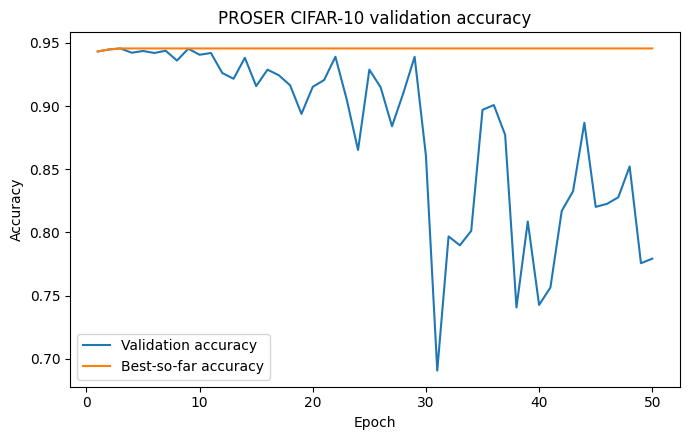

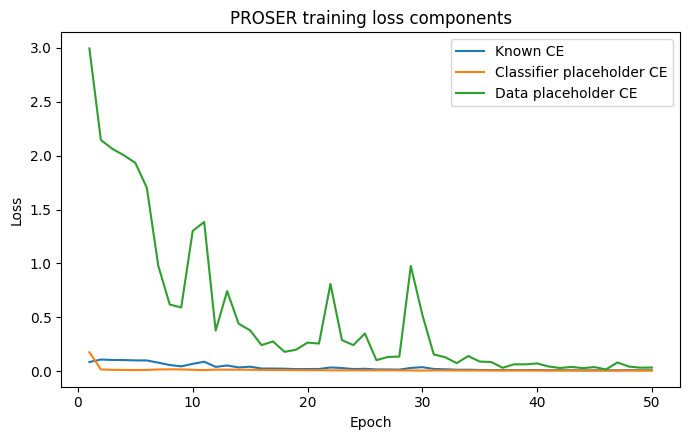

Saved validation-only figures: /content/drive/MyDrive/pa1-beyond-iid/task4/results/proser


In [10]:
#! Save compact PROSER training and validation-only diagnostic figures
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

plt.figure(figsize=(7, 4.5))

plt.plot(history_df['epoch'], history_df['val_accuracy'], label='Validation accuracy')
plt.plot(history_df['epoch'], history_df['best_val_accuracy'], label='Best-so-far accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('PROSER CIFAR-10 validation accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'validation_accuracy.png', dpi=180)

plt.show()

plt.figure(figsize=(7, 4.5))

plt.plot(history_df['epoch'], history_df['train_known_ce'], label='Known CE')
plt.plot(history_df['epoch'], history_df['train_second_place_ce'], label='Classifier placeholder CE')
plt.plot(history_df['epoch'], history_df['train_data_placeholder_loss'], label='Data placeholder CE')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PROSER training loss components')
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'loss_components.png', dpi=180)

plt.show()

print('Saved validation-only figures:', RESULT_DIR)


In [11]:
#! Final disk audit: training complete, selected checkpoint consistent, no unknown-data dependency
last = torch.load(LAST_PATH, map_location='cpu', weights_only=False)
best = torch.load(BEST_PATH, map_location='cpu', weights_only=False)

if last['epoch'] != EPOCHS or not last['finished'] or len(last['history']) != EPOCHS:
    raise RuntimeError('PROSER did not complete all 50 epochs.')

if best['epoch'] != last['best_epoch']:
    raise RuntimeError('PROSER selected checkpoint and training history disagree.')

if abs(float(best['best_val_accuracy']) - float(last['best_val_accuracy'])) > 1e-12:
    raise RuntimeError('PROSER best validation accuracy mismatch.')

if not CALIBRATION_FILE.exists() or not VAL_CACHE.exists():
    raise RuntimeError('PROSER validation calibration artifacts are missing.')

saved_calibration = json.loads(CALIBRATION_FILE.read_text())

if saved_calibration['best_checkpoint_sha256'] != hashlib.sha256(BEST_PATH.read_bytes()).hexdigest():
    raise RuntimeError('Calibration was not produced from the current selected checkpoint.')

with np.load(VAL_CACHE) as saved:
    if (saved['known_logits'].shape != (5000, 10)
            or saved['dummy_logits'].shape != (5000, 5)
            or not np.array_equal(saved['indices'], val_idx)
            or not np.array_equal(saved['labels'], targets[val_idx])):
        raise RuntimeError('PROSER validation cache audit failed.')

print('TASK 4D COMPLETE')
print('Selected PROSER epoch:', best['epoch'])
print('Best CIFAR-10 validation accuracy:', round(best['best_val_accuracy'], 5))
print('Best checkpoint:', BEST_PATH)
print('Validation calibration:', CALIBRATION_FILE)
print('CIFAR-10 TEST AND ALL CIFAR-100 EXAMPLES HAVE NOT BEEN ACCESSED.')


TASK 4D COMPLETE
Selected PROSER epoch: 3
Best CIFAR-10 validation accuracy: 0.9456
Best checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task4/checkpoints/proser/best.pt
Validation calibration: /content/drive/MyDrive/pa1-beyond-iid/task4/results/proser/calibration.json
CIFAR-10 TEST AND ALL CIFAR-100 EXAMPLES HAVE NOT BEEN ACCESSED.
